In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## 1. Setup Paths & Configuration

import sys
import os
from pathlib import Path

# Add source directory to path
current_path = Path.cwd()
base_project_dir = current_path.parent
src_dir = base_project_dir / "src"

if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

# Define key directories
dataset_directory = src_dir / "abstractionsshapecoder" / "dataset"
saved_directory = src_dir / "abstractionsshapecoder" / "saved"

# --- AE Model Paths ---
saved_models_L1_AE_dir = saved_directory / "models_L1_AE"
saved_models_L2_AE_dir = saved_directory / "models_L2_AE"
saved_models_L1_AE_dir.mkdir(parents=True, exist_ok=True)
saved_models_L2_AE_dir.mkdir(parents=True, exist_ok=True)

# --- PCA Model Paths ---
saved_models_L1_PCA_dir = saved_directory / "models_L1_PCA"
saved_models_L2_PCA_dir = saved_directory / "models_L2_PCA"
saved_models_L1_PCA_dir.mkdir(parents=True, exist_ok=True)
saved_models_L2_PCA_dir.mkdir(parents=True, exist_ok=True)

print(f"Base project directory: {base_project_dir}")
print(f"Source directory: {src_dir}")
print(f"L1 AE Models directory: {saved_models_L1_AE_dir}")
print(f"L2 AE Models directory: {saved_models_L2_AE_dir}")
print(f"L1 PCA Models directory: {saved_models_L1_PCA_dir}")
print(f"L2 PCA Models directory: {saved_models_L2_PCA_dir}")

Base project directory: c:\Users\Amogh\abstraction-discovery
Source directory: c:\Users\Amogh\abstraction-discovery\src
L1 AE Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE
L2 AE Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L2_AE
L1 PCA Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_PCA
L2 PCA Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L2_PCA


In [3]:
import pickle
from pathlib import Path
from abstractionsshapecoder.debug_utils import debug_info, debug_success, debug_error

def load_processed_datasets():
    """
    Loads all hierarchical datasets (L0, L1-VAE, L1-AE, L2-AE) from the saved directory.
    """
    SAVED_DIR = Path.cwd().parent / "src" / "abstractionsshapecoder" / "saved"
    
    # Define file map: {Variable_Name: Filename}
    dataset_files = {
        "shapes_l0": "all_dsl_shapes.pkl",
        "shapes_l1_vae": "all_abstracted_shapes_L1_VAE.pkl",
        "shapes_l1_ae": "all_abstracted_shapes_L1_AE.pkl",
        "shapes_l2_ae": "all_abstracted_shapes_L2_AE.pkl"
    }
    
    loaded_datasets = {}
    
    for var_name, filename in dataset_files.items():
        file_path = SAVED_DIR / filename
        if file_path.exists():
            debug_info(f"Loading {var_name} from {filename}...")
            with open(file_path, "rb") as f:
                loaded_datasets[var_name] = pickle.load(f)
            debug_success(f"Successfully loaded {len(loaded_datasets[var_name])} shapes into {var_name}.")
        else:
            debug_error(f"Missing file: {filename}. Ensure previous training cells were run.")
            loaded_datasets[var_name] = {}
            
    return loaded_datasets

# Execute the load
datasets = load_processed_datasets()

# Extract into global namespace for easier access in subsequent cells
shapes_l0 = datasets.get("shapes_l0")

[INFO] Loading shapes_l0 from all_dsl_shapes.pkl...
[SUCCESS] Successfully loaded 1100 shapes into shapes_l0.
[INFO] Loading shapes_l1_vae from all_abstracted_shapes_L1_VAE.pkl...
[SUCCESS] Successfully loaded 1100 shapes into shapes_l1_vae.
[ERROR] Missing file: all_abstracted_shapes_L1_AE.pkl. Ensure previous training cells were run.
[ERROR] Missing file: all_abstracted_shapes_L2_AE.pkl. Ensure previous training cells were run.


In [4]:
print(shapes_l0["2741_0_343"]["dsl"])

Union(
    Translate(vec=[-0.000, -0.180, 0.170])
        Cuboid(size=[0.770, 0.300, 0.870]),
    Union(
        Rotate(quat=[-0.1395, 0.0000, 0.0000, 0.9902])
            Translate(vec=[-0.000, 0.290, -0.300])
                Cuboid(size=[0.770, 0.940, 0.360]),
        Union(
            Translate(vec=[-0.400, 0.050, 0.050])
                Cuboid(size=[0.050, 0.500, 0.500]),
            Union(
                Translate(vec=[0.400, 0.050, 0.050])
                    Cuboid(size=[0.050, 0.500, 0.500]),
                Union(
                    Rotate(quat=[0.0000, 0.0000, 0.0150, 0.9999])
                        Rotate(quat=[0.1346, 0.0000, 0.0000, 0.9909])
                            Translate(vec=[-0.340, -0.550, -0.120])
                                Cuboid(size=[0.070, 0.480, 0.070]),
                    Union(
                        Rotate(quat=[0.0000, 0.0000, 0.0150, 0.9999])
                            Rotate(quat=[-0.1346, 0.0000, 0.0000, 0.9909])
                         

In [5]:
shapes_l0["172_0_0"]

{'dsl': <abstractionsshapecoder.dsl_nodes.Union at 0x295292165d0>,
 'singleton_params': {'Cuboid': [[0.68, 0.09, 0.66],
   [0.06, 0.6, 0.06],
   [0.06, 0.6, 0.06],
   [0.06, 0.6, 0.06],
   [0.06, 0.6, 0.06],
   [0.08, 0.79, 0.08],
   [0.08, 0.79, 0.08],
   [0.68, 0.14, 0.24],
   [0.08, 0.79, 0.08],
   [0.08, 0.79, 0.08],
   [0.08, 0.79, 0.08]],
  'Translate': [[-0.0, -0.17, 0.0],
   [-0.31, -0.51, -0.17],
   [-0.31, -0.51, 0.3],
   [0.31, -0.51, -0.17],
   [0.31, -0.51, 0.3],
   [-0.26, 0.27, -0.18],
   [-0.14, 0.27, -0.25],
   [0.0, 0.74, -0.22],
   [-0.0, 0.27, -0.25],
   [0.14, 0.27, -0.25],
   [0.28, 0.27, -0.25]]},
 'pair_params': {'Translate(Cuboid)': [[-0.0, -0.17, 0.0, 0.68, 0.09, 0.66],
   [-0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
   [-0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
   [0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
   [0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
   [-0.26, 0.27, -0.18, 0.08, 0.79, 0.08],
   [-0.14, 0.27, -0.25, 0.08, 0.79, 0.08],
   [0.0, 0.74, -0.22, 0.68, 0.14, 0.24],
  

In [6]:
shapes_l0["172_0_0"]["dsl"]

In [7]:
print(shapes_l0["172_0_0"]["dsl"])

Union(
    Translate(vec=[-0.000, -0.170, 0.000])
        Cuboid(size=[0.680, 0.090, 0.660]),
    Union(
        Translate(vec=[-0.310, -0.510, -0.170])
            Cuboid(size=[0.060, 0.600, 0.060]),
        Union(
            Translate(vec=[-0.310, -0.510, 0.300])
                Cuboid(size=[0.060, 0.600, 0.060]),
            Union(
                Translate(vec=[0.310, -0.510, -0.170])
                    Cuboid(size=[0.060, 0.600, 0.060]),
                Union(
                    Translate(vec=[0.310, -0.510, 0.300])
                        Cuboid(size=[0.060, 0.600, 0.060]),
                    Union(
                        Translate(vec=[-0.260, 0.270, -0.180])
                            Cuboid(size=[0.080, 0.790, 0.080]),
                        Union(
                            Translate(vec=[-0.140, 0.270, -0.250])
                                Cuboid(size=[0.080, 0.790, 0.080]),
                            Union(
                                Translate(vec=[0.000, 0

In [8]:
from collections import defaultdict
from tqdm.auto import tqdm

debug_info("Extracting L1 Singleton and Pair parameters...")

combined_singletons_L1 = defaultdict(list)
combined_pairs_L1 = defaultdict(list)

for filename, data in tqdm(shapes_l0.items(), desc="Aggregating L1"):
    # Extract Singletons
    for p_name, p_lists in data["singleton_params"].items():
        if "Box" in p_name: continue
        for p_list in p_lists or []:
            # Dimension-safe key: e.g., "Translate_dim3"
            key = f"{p_name}_dim{len(p_list)}"
            combined_singletons_L1[key].append(p_list)
            
    # Extract Pairs
    for p_name, p_lists in data["pair_params"].items():
        if "Box" in p_name: continue
        for p_list in p_lists or []:
            key = f"{p_name}_dim{len(p_list)}"
            combined_pairs_L1[key].append(p_list)

debug_success(f"Extracted {len(combined_singletons_L1)} singleton and {len(combined_pairs_L1)} pair patterns.")

[INFO] Extracting L1 Singleton and Pair parameters...


Aggregating L1:   0%|          | 0/1100 [00:00<?, ?it/s]

[SUCCESS] Extracted 3 singleton and 5 pair patterns.


[INFO] Starting abstraction search for 3 L1_SINGLETONS...
[INFO] Structures sorted by sample count (descending).
[INFO] Using abstraction method: AE
[INFO] 
--- Processing pattern 'Cuboid_dim3' (10268 samples) ---
[INFO] Parameter dimension for 'Cuboid_dim3': 3
[INFO] -- Iteration 1 for 'Cuboid_dim3' --
[INFO] Initializing Autoencoder: input_dim=3, hidden_dim=2
[SUCCESS] Autoencoder initialized successfully.


Training Cuboid_dim3:   0%|          | 0/3220 [00:00<?, ?batch/s]

[SUCCESS] Saved loss chart to c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE\cuboid_dim3.loss_chart.png


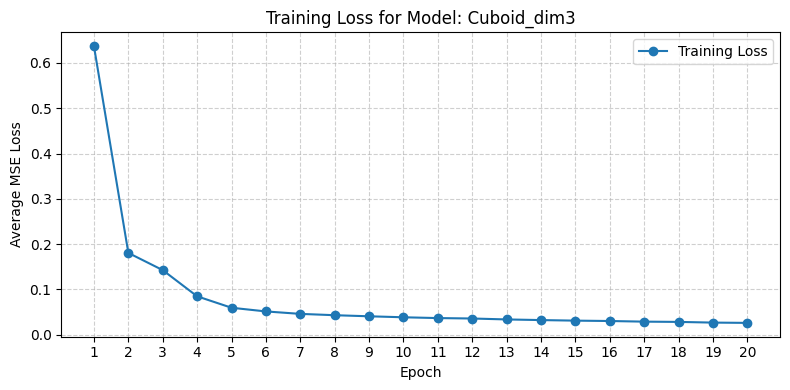

[INFO] Recomputing mask for 'Cuboid_dim3'...
[INFO] [Cuboid_dim3 Iter 1] Kept 8155/10268 samples.
[SUCCESS] Stored final model for 'Cuboid_dim3'.
[INFO] 
--- Processing pattern 'Translate_dim3' (10268 samples) ---
[INFO] Parameter dimension for 'Translate_dim3': 3
[INFO] -- Iteration 1 for 'Translate_dim3' --
[INFO] Initializing Autoencoder: input_dim=3, hidden_dim=2
[SUCCESS] Autoencoder initialized successfully.


Training Translate_dim3:   0%|          | 0/3220 [00:00<?, ?batch/s]

[SUCCESS] Saved loss chart to c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE\translate_dim3.loss_chart.png


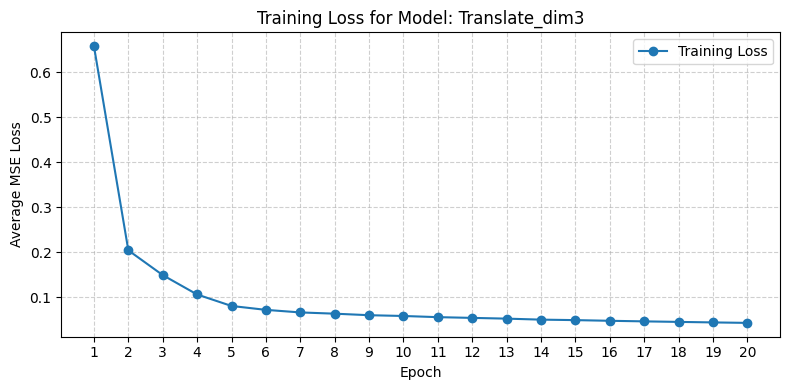

[INFO] Recomputing mask for 'Translate_dim3'...
[INFO] [Translate_dim3 Iter 1] Kept 6236/10268 samples.
[SUCCESS] Stored final model for 'Translate_dim3'.
[INFO] 
--- Processing pattern 'Rotate_dim4' (3416 samples) ---
[INFO] Parameter dimension for 'Rotate_dim4': 4
[INFO] -- Iteration 1 for 'Rotate_dim4' --
[INFO] Initializing Autoencoder: input_dim=4, hidden_dim=3
[SUCCESS] Autoencoder initialized successfully.


Training Rotate_dim4:   0%|          | 0/1080 [00:00<?, ?batch/s]

[SUCCESS] Saved loss chart to c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE\rotate_dim4.loss_chart.png


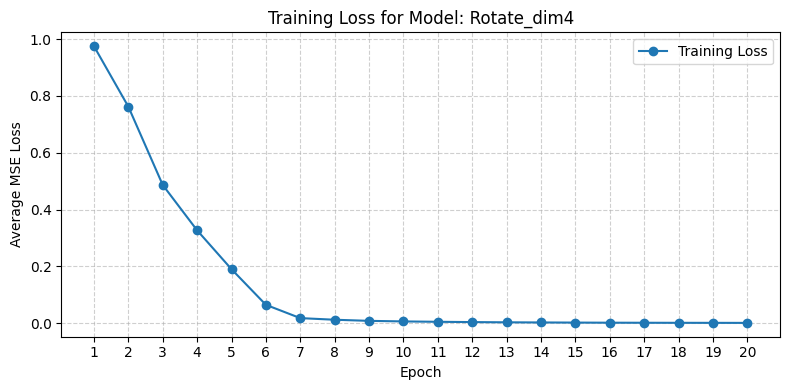

[INFO] Recomputing mask for 'Rotate_dim4'...
[INFO] [Rotate_dim4 Iter 1] Kept 3383/3416 samples.
[SUCCESS] Stored final model for 'Rotate_dim4'.
[SUCCESS] Finished abstraction search. Created 3 models.
[INFO] Starting abstraction search for 5 L1_PAIRS...
[INFO] Structures sorted by sample count (descending).
[INFO] Using abstraction method: AE
[INFO] 
--- Processing pattern 'Translate(Cuboid)_dim6' (10268 samples) ---
[INFO] Parameter dimension for 'Translate(Cuboid)_dim6': 6
[INFO] -- Iteration 1 for 'Translate(Cuboid)_dim6' --
[INFO] Initializing Autoencoder: input_dim=6, hidden_dim=5
[SUCCESS] Autoencoder initialized successfully.


Training Translate(Cuboid)_dim6:   0%|          | 0/3220 [00:00<?, ?batch/s]

[SUCCESS] Saved loss chart to c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE\translate_cuboid_dim6.loss_chart.png


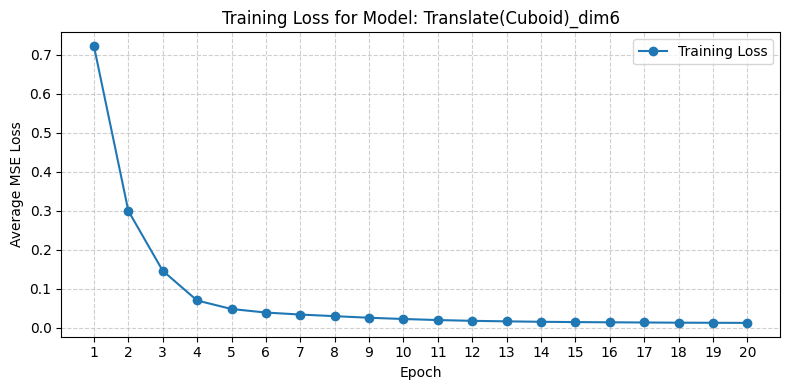

[INFO] Recomputing mask for 'Translate(Cuboid)_dim6'...
[INFO] [Translate(Cuboid)_dim6 Iter 1] Kept 8241/10268 samples.
[SUCCESS] Stored final model for 'Translate(Cuboid)_dim6'.
[INFO] 
--- Processing pattern 'Union(Translate)_dim3' (8656 samples) ---
[INFO] Parameter dimension for 'Union(Translate)_dim3': 3
[INFO] -- Iteration 1 for 'Union(Translate)_dim3' --
[INFO] Initializing Autoencoder: input_dim=3, hidden_dim=2
[SUCCESS] Autoencoder initialized successfully.


Training Union(Translate)_dim3:   0%|          | 0/2720 [00:00<?, ?batch/s]

[SUCCESS] Saved loss chart to c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE\union_translate_dim3.loss_chart.png


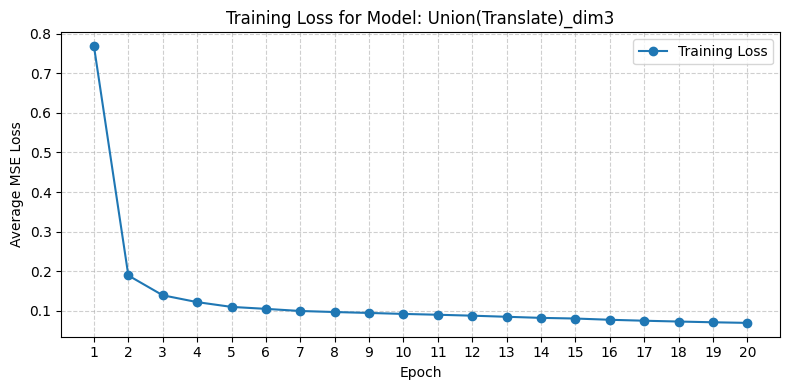

[INFO] Recomputing mask for 'Union(Translate)_dim3'...
[INFO] [Union(Translate)_dim3 Iter 1] Kept 4321/8656 samples.
[SUCCESS] Stored final model for 'Union(Translate)_dim3'.
[INFO] 
--- Processing pattern 'Rotate(Rotate)_dim8' (1804 samples) ---
[INFO] Parameter dimension for 'Rotate(Rotate)_dim8': 8
[INFO] -- Iteration 1 for 'Rotate(Rotate)_dim8' --
[INFO] Initializing Autoencoder: input_dim=8, hidden_dim=7
[SUCCESS] Autoencoder initialized successfully.


Training Rotate(Rotate)_dim8:   0%|          | 0/580 [00:00<?, ?batch/s]

[SUCCESS] Saved loss chart to c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE\rotate_rotate_dim8.loss_chart.png


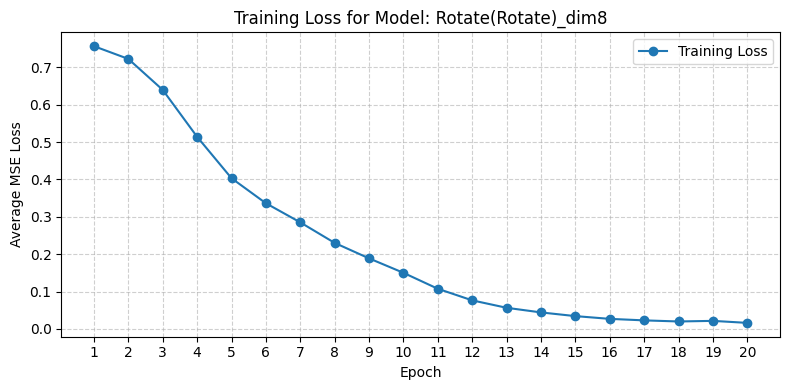

[INFO] Recomputing mask for 'Rotate(Rotate)_dim8'...
[INFO] [Rotate(Rotate)_dim8 Iter 1] Kept 1374/1804 samples.
[SUCCESS] Stored final model for 'Rotate(Rotate)_dim8'.
[INFO] 
--- Processing pattern 'Rotate(Translate)_dim7' (1612 samples) ---
[INFO] Parameter dimension for 'Rotate(Translate)_dim7': 7
[INFO] -- Iteration 1 for 'Rotate(Translate)_dim7' --
[INFO] Initializing Autoencoder: input_dim=7, hidden_dim=6
[SUCCESS] Autoencoder initialized successfully.


Training Rotate(Translate)_dim7:   0%|          | 0/520 [00:00<?, ?batch/s]

[SUCCESS] Saved loss chart to c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE\rotate_translate_dim7.loss_chart.png


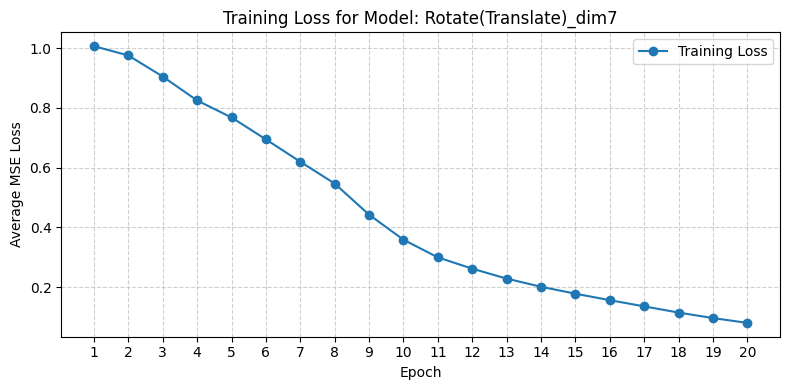

[INFO] Recomputing mask for 'Rotate(Translate)_dim7'...
[INFO] [Rotate(Translate)_dim7 Iter 1] Kept 361/1612 samples.
[SUCCESS] Stored final model for 'Rotate(Translate)_dim7'.
[INFO] 
--- Processing pattern 'Union(Rotate)_dim4' (1612 samples) ---
[INFO] Parameter dimension for 'Union(Rotate)_dim4': 4
[INFO] -- Iteration 1 for 'Union(Rotate)_dim4' --
[INFO] Initializing Autoencoder: input_dim=4, hidden_dim=3
[SUCCESS] Autoencoder initialized successfully.


Training Union(Rotate)_dim4:   0%|          | 0/520 [00:00<?, ?batch/s]

[SUCCESS] Saved loss chart to c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE\union_rotate_dim4.loss_chart.png


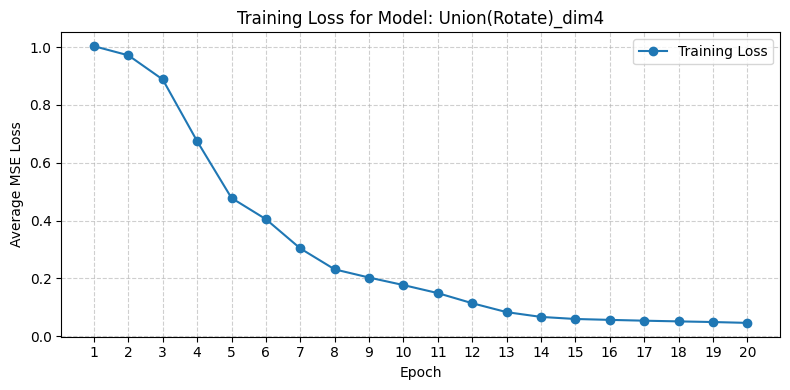

[INFO] Recomputing mask for 'Union(Rotate)_dim4'...
[INFO] [Union(Rotate)_dim4 Iter 1] Kept 1526/1612 samples.
[SUCCESS] Stored final model for 'Union(Rotate)_dim4'.
[SUCCESS] Finished abstraction search. Created 5 models.


In [13]:
# Train Singletons
from abstractionssymh.abstraction_utils import find_abstractions


models_l1_singletons = find_abstractions(
    combined_singletons_L1, 
    method='ae', 
    structure_type="L1_SINGLETONS", 
    min_examples=20, 
    epochs=20,
    error_threshold=0.2,
    save_dir=saved_models_L1_AE_dir
)

# Train Pairs
models_l1_pairs = find_abstractions(
    combined_pairs_L1, 
    method='ae', 
    structure_type="L1_PAIRS", 
    min_examples=20, 
    epochs=20,
    error_threshold=0.2,
    save_dir=saved_models_L1_AE_dir
)

In [16]:
from abstractionssymh.abstraction_utils import integrate_abstractions
from abstractionssymh.dsl_utils import collect_singleton_and_pair_data
import pickle

debug_info("--- Creating L1-AE Abstracted Dataset ---")

shapes_l1_ae = {}
# Using a high error_threshold for integration to ensure the models apply
INTEGRATION_THRESHOLD = 0.5 

for filename, data in tqdm(shapes_l0.items(), desc="Integrating L1-AE"):
    # 1. Apply the models to the DSL tree
    abstracted_dsl = integrate_abstractions(
        data["dsl"],
        models_l1_singletons,
        models_l1_pairs,
        error_threshold=INTEGRATION_THRESHOLD,
        detailed_debug=False # Set to True if you want to see why specific nodes fail
    )

    # 2. Collect parameters (These are now the Latent Vectors from your AE)
    l1_singletons, l1_pairs = collect_singleton_and_pair_data([abstracted_dsl])

    shapes_l1_ae[filename] = {
        "dsl": abstracted_dsl,
        "singleton_params": l1_singletons,
        "pair_params": l1_pairs,
        "original_dsl": data["dsl"]
    }

# Save the progress
pickle_file_L1_AE = saved_directory / "all_abstracted_shapes_L1_AE.pkl"
with open(pickle_file_L1_AE, "wb") as f:
    pickle.dump(shapes_l1_ae, f)

debug_success(f"Created L1-AE dataset with {len(shapes_l1_ae)} shapes.")

[INFO] --- Creating L1-AE Abstracted Dataset ---


Integrating L1-AE:   0%|          | 0/1100 [00:00<?, ?it/s]

    [EGGLOG] Attempting refactor on subtree...
      [EGGLOG] Attempting refactor on subtree...
        [EGGLOG] Attempting refactor on subtree...
          [EGGLOG] Attempting refactor on subtree...
            [EGGLOG] Attempting refactor on subtree...
              [EGGLOG] Attempting refactor on subtree...
                [EGGLOG] Attempting refactor on subtree...
                  [EGGLOG] Attempting refactor on subtree...
                    [EGGLOG] Attempting refactor on subtree...
                      [EGGLOG] Attempting refactor on subtree...
                      [EGGLOG] Attempting refactor on subtree...
                  [EGGLOG] Attempting refactor on subtree...
              [EGGLOG] Attempting refactor on subtree...
          [EGGLOG] Attempting refactor on subtree...
      [EGGLOG] Attempting refactor on subtree...
  [EGGLOG] Attempting refactor on subtree...
    [EGGLOG] Attempting refactor on subtree...
      [EGGLOG] Attempting refactor on subtree...
        [EGGLO

NameError: name 'cuboid' is not defined